In [1]:
import os
import glob
import iris
import pandas as pd
import numpy as np
import logging
#import esmvalcore.preprocessor
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats as stats

matplotlib.rcParams.update({'font.size': 14})
from config import path_archive

model_colors = {'UKESM':'salmon',
                'CESM':'lightskyblue',
                'E3SM':'seagreen'}

dark_model_colors = {'UKESM':'orangered',
                     'CESM':'deepskyblue',
                     'E3SM':'seagreen'}

In [2]:
### options

assessment_period = ['1991', '2015']

In [3]:
ens_mems = [x.split('/')[9] for x in glob.glob('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/*/AERmon/ztp')]
def get_ds(variable, table='Amon', grid='gn'):
    ds_list = []
    for es in ens_mems:
        path = '/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/{e}/{t}/{v}/{g}/latest/'.format(e=es, t=table,v=variable, g=grid)
        #files = os.listdir(path)
        ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
        ds_list.append(ds)
    
    DS = xr.concat(ds_list, dim='Ensemble_member')
    return DS

DS = get_ds(variable='ztp', table='AERmon', grid='gn')
DS = DS.sel(time=slice(assessment_period[0], assessment_period[1]))
DS_UKESM = DS.mean(dim='Ensemble_member').mean('x').groupby('time.month').mean('time')
DS_UKESM_ES = get_ds(variable='ztp', table='AERmon', grid='gn').sel(time=slice(assessment_period[0], assessment_period[1])).mean('x').groupby('time.month').mean('time')
DS_UKESM_E1 = get_ds(variable='ztp', table='AERmon', grid='gn').isel(Ensemble_member=0).sel(time=slice(assessment_period[0], assessment_period[1])).mean('x')

In [4]:
import os
import glob
#os.listdir('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/day/')
glob.glob('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/*/ztp')

['/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/AERmon/ztp']

In [5]:
CESM_ens_mems = [1, 2, 3]

ds_list = []
for ens_mem in CESM_ens_mems:
    CESM_path = '/gws/ssde/j25b/cpom/aduffey/Tropopause/CMIP6/CESM2WACCM/historical/r{}i1p1f1'.format(ens_mem)
    CESM_file = '/ztp_AERmon_CESM2-WACCM_historical_r{}i1p1f1_gn_185001-201412.nc'.format(ens_mem)
    file =  CESM_path + CESM_file
    ds = rename_cmip6(xr.open_dataset(file))
    ds_list.append(ds)
DS_CESM = xr.concat(ds_list, dim='Ensemble_member')
DS_CESM = DS_CESM.sel(time=slice(assessment_period[0], assessment_period[1])).mean(dim='Ensemble_member').mean('x').groupby('time.month').mean('time')

DS_CESM_ES = xr.concat(ds_list, dim='Ensemble_member').sel(time=slice(assessment_period[0], assessment_period[1])).mean('x').groupby('time.month').mean('time')
DS_CESM_E1 = ds_list[0].sel(time=slice(assessment_period[0], assessment_period[1])).mean('x')

/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'ztp' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'ztp' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'ztp' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [6]:
#DS_UKESM.ztp.plot.contourf()
#DS_CESM.ztp.plot.contourf()

In [7]:
mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM.mean(dim='month').ztp/1000).load(), (DS_UKESM.max(dim='month').ztp/1000).load(), (DS_UKESM.min(dim='month').ztp/1000).load()
mean_trop_C, max_trop_C, min_trop_C = (DS_CESM.mean(dim='month').ztp/1000).load(), (DS_CESM.max(dim='month').ztp/1000).load(), (DS_CESM.min(dim='month').ztp/1000).load()

Annual variation of ensemble means (monthly resolution)


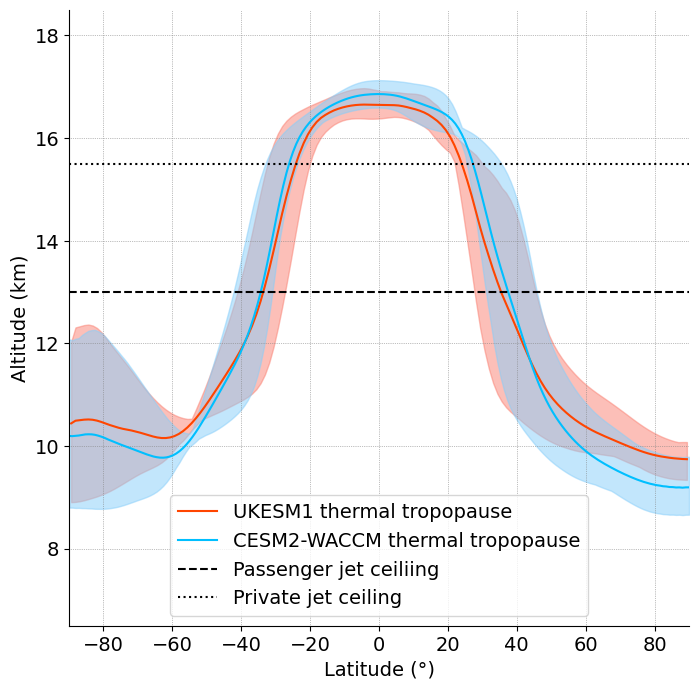

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
t_col = 'black'

mean_trop_U.plot(ax=ax, c=dark_model_colors['UKESM'])
mean_trop_C.plot(ax=ax, c=dark_model_colors['CESM'])
ax.fill_between(max_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
                color=model_colors['UKESM'], alpha=0.5)
ax.fill_between(max_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
                color=model_colors['CESM'], alpha=0.5)

ax.axhline(15.5, c='black', ls='dotted')
ax.axhline(13, c='black', ls='dashed')

ax.plot([], [], c=dark_model_colors['UKESM'], label='UKESM1 thermal tropopause')
ax.plot([], [], c=dark_model_colors['CESM'], label='CESM2-WACCM thermal tropopause')
ax.plot([], [], c='black', ls='dashed', label='Passenger jet ceiliing')
ax.plot([], [], c='black', ls='dotted',  label='Private jet ceiling')
#ax.plot([], [], c='red', ls = '--', label='"high altitude"')
ax.legend(loc='lower center')

ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Altitude (km)')
ax.set_xlim([-90, 90])
ax.set_ylim([6.5, 18.5])
ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)

ax.spines[['right', 'top']].set_visible(False)
print('Annual variation of ensemble means (monthly resolution)')
plt.savefig('Figures/UKESM_CESM_mean_and_annual_spread.jpg', dpi=350)

In [9]:
## now repeat, with reanalyses added

### downloaded reanalysis zonal mean troppause heights from Hoffman & Spang
# https://acp.copernicus.org/articles/22/4019/2022/acp-22-4019-2022-assets.html
# use the WMO thermal 1st tropopause (as in ztp calc)
# https://datapub.fz-juelich.de/slcs/tropopause/data/projects/zonal_mean/README.txt

# NB we include ERA5 even though it doesn't include the 1990-2000 period. 
from scipy.interpolate import griddata

root = '/gws/ssde/j25b/cpom/aduffey/Tropopause/zonal_means_HoffmanSpang/'
#dir = root+reanalysis+'/'

dfs_all = []
reanalyses = ['ERA5', 'ERAi', 'MERRA2', 'NCEP','NCEP2']

for reanalysis in reanalyses:
    dir = root+reanalysis+'/'
    dfs_reanalysis = []
    for file in os.listdir(dir):
        year = file.split('_')[-2]
        month = file.split('_')[-1].split('.')[0]
        if int(year) >= int(assessment_period[0]) and int(year) <= int(assessment_period[1]):
            df = pd.read_csv(dir+file, 
                        delimiter=" ",
                        skiprows=14,
                        header=None)
            df = df.iloc[:, 0:3] 
            df.columns = ['time [s]',
                          'latitude [deg]',
                          'tropopause height (mean) [km]']
            grid_lat_new = np.arange(-90, 90.1, 0.1)
            regridded_ztp = griddata(df['latitude [deg]'], df['tropopause height (mean) [km]'], grid_lat_new, method='linear')
            df_regridded = pd.DataFrame({'Latitude_deg':grid_lat_new,
                                         'ztp_km':regridded_ztp})
            df_regridded['Year'] = year
            df_regridded['Month'] = month
            df_regridded['Reanalysis'] = reanalysis
            dfs_reanalysis.append(df_regridded)
    df_reanalysis = pd.concat(dfs_reanalysis)
    dfs_all.append(df_reanalysis)
DF = pd.concat(dfs_all)
DF['Month'] = [int(x) for x in DF['Month']]
DF['Year'] = [int(x) for x in DF['Year']]

In [10]:
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

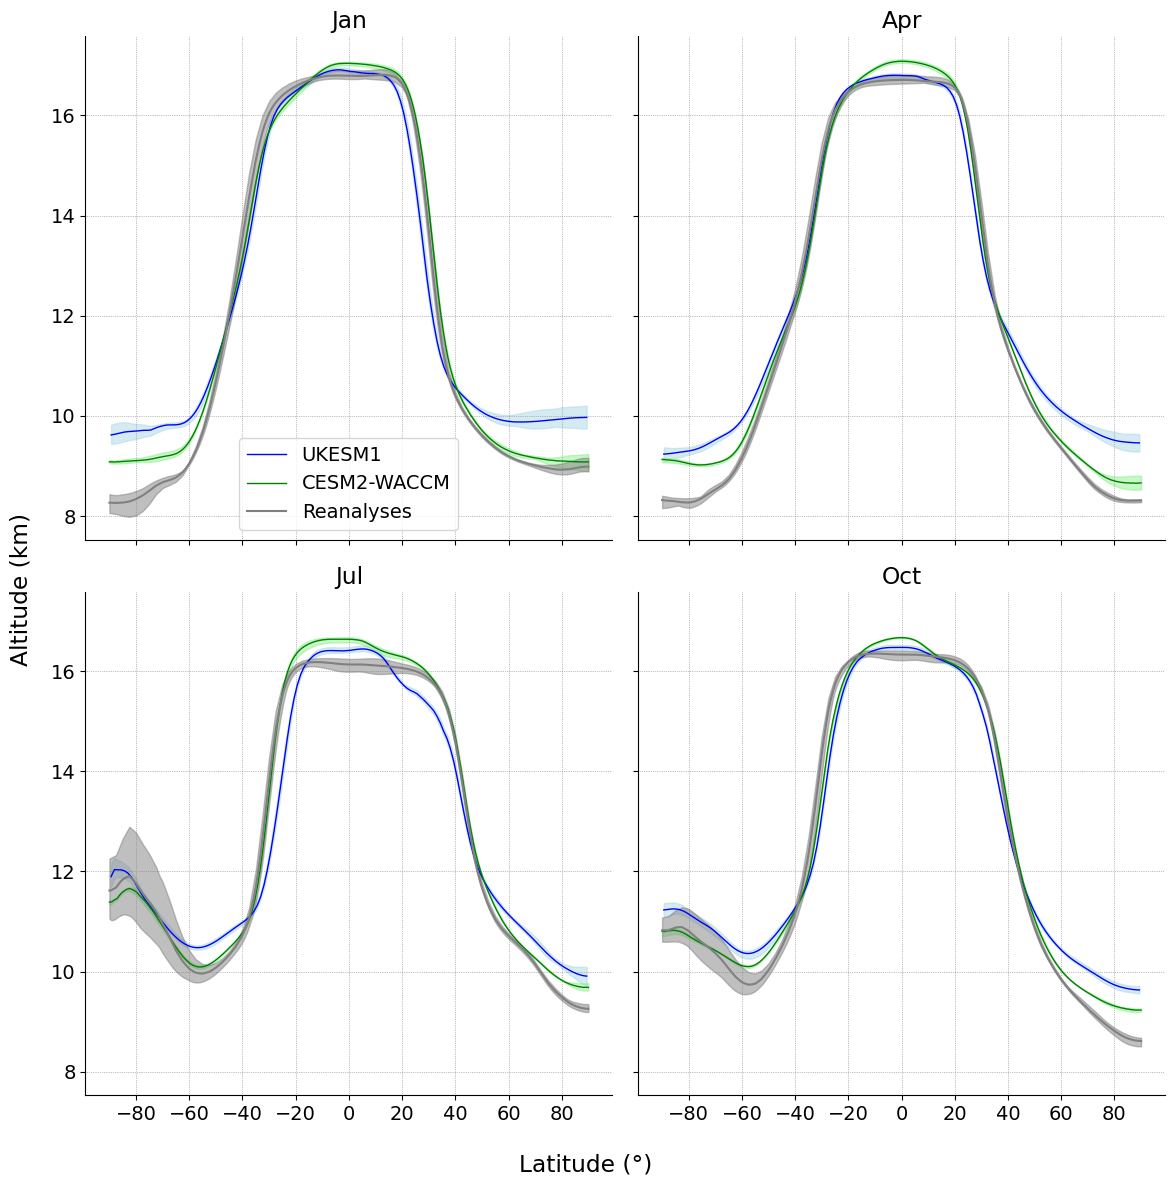

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
months = [1, 4, 7, 10]
titles = ['Jan', 'Apr', 'Jul', 'Oct']
i=0

for ax in axs.flatten():
        
    month = months[i]
    ds = DS_UKESM.sel(month=month)
    ax.plot(ds.y.values, ds.ztp.values*0.001, label='UKESM1', color='blue', lw=1)
    ds_max = DS_UKESM_ES.sel(month=month).max(dim='Ensemble_member')
    ds_min = DS_UKESM_ES.sel(month=month).min(dim='Ensemble_member')
    ax.fill_between(ds_max.y.values, ds_min.ztp.values*0.001, ds_max.ztp.values*0.001, 
                color='lightblue', alpha=0.5)
    
    ds = DS_CESM.sel(month=month)
    ax.plot(ds.y.values, ds.ztp.values*0.001, label='CESM2-WACCM', color='green', lw=1)
    ds_max = DS_CESM_ES.sel(month=month).max(dim='Ensemble_member')
    ds_min = DS_CESM_ES.sel(month=month).min(dim='Ensemble_member')
    ax.fill_between(ds_max.y.values, ds_min.ztp.values*0.001, ds_max.ztp.values*0.001, 
                color='lightgreen', alpha=0.5)

    df = DF[DF['Month']==month]
    df = df[['Reanalysis', 'Latitude_deg', 'ztp_km']].groupby(['Reanalysis', 'Latitude_deg']).mean().reset_index()
    df_max = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_km'], df_max['ztp_km'], 
                color='gray', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_km'], color='gray', label='Reanalyses')
    ax.set_xticks(np.arange(-80, 85, 20))
    if i == 0:
        ax.legend()
    ax.set_title(titles[i])
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
    i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()
#plt.savefig('Figures/Tropopause_UKESMandCESM_vs_reanalyses.jpg', dpi=300)

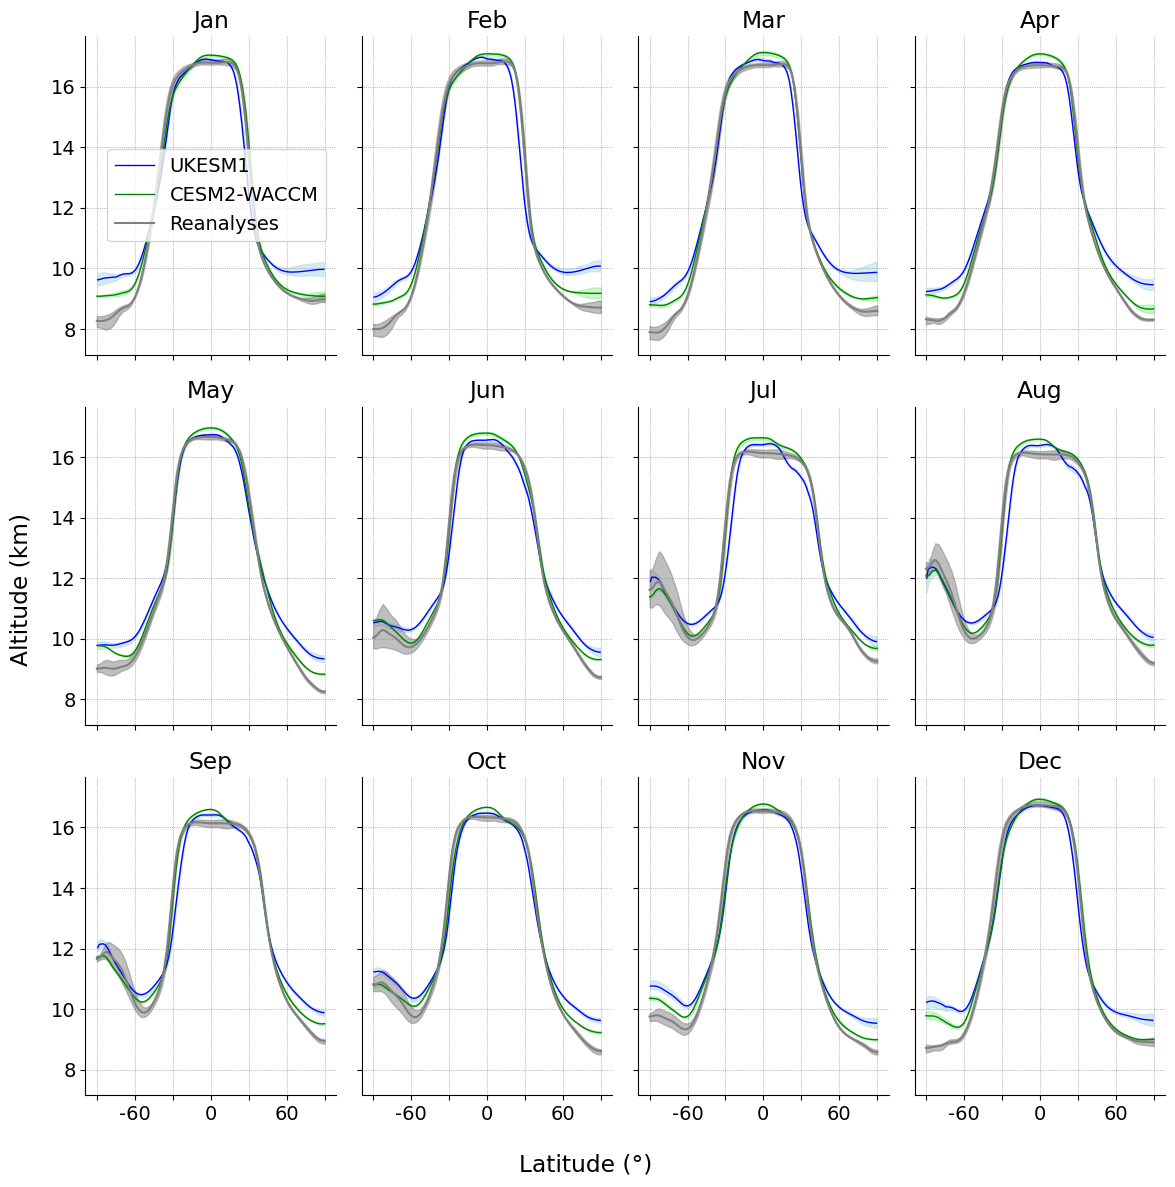

In [12]:
### now repeat, this time showing min max range of members:
fig, axs = plt.subplots(3, 4, figsize=(12, 12), sharex=True, sharey=True)

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
titles = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
i=0

for ax in axs.flatten():
        
    month = months[i]
    ds = DS_UKESM.sel(month=month)
    ax.plot(ds.y.values, ds.ztp.values*0.001, label='UKESM1', color='blue', lw=1)
    ds_max = DS_UKESM_ES.sel(month=month).max(dim='Ensemble_member')
    ds_min = DS_UKESM_ES.sel(month=month).min(dim='Ensemble_member')
    ax.fill_between(ds_max.y.values, ds_min.ztp.values*0.001, ds_max.ztp.values*0.001, 
                color='lightblue', alpha=0.5)
    
    ds = DS_CESM.sel(month=month)
    ax.plot(ds.y.values, ds.ztp.values*0.001, label='CESM2-WACCM', color='green', lw=1)
    ds_max = DS_CESM_ES.sel(month=month).max(dim='Ensemble_member')
    ds_min = DS_CESM_ES.sel(month=month).min(dim='Ensemble_member')
    ax.fill_between(ds_max.y.values, ds_min.ztp.values*0.001, ds_max.ztp.values*0.001, 
                color='lightgreen', alpha=0.5)

    df = DF[DF['Month']==month]
    df = df[['Reanalysis', 'Latitude_deg', 'ztp_km']].groupby(['Reanalysis', 'Latitude_deg']).mean().reset_index()
    df_max = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_km'], df_max['ztp_km'], 
                color='gray', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_km'], color='gray', label='Reanalyses')
    ax.set_xticks(np.arange(-90, 95, 30))
    ax.set_xticklabels(['', '-60', '', '0', '' , '60', ''])
    if i == 0:
        ax.legend()
    ax.set_title(titles[i])
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
    i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()
#plt.savefig('Figures/Tropopause_UKESMandCESM_vs_reanalyses_fullyear.jpg', dpi=300)

In [13]:
## also plot the year-to-year variability for one member, and for MERRA2:

month = 1

DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month == month, drop=True)
DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month == month, drop=True)

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()

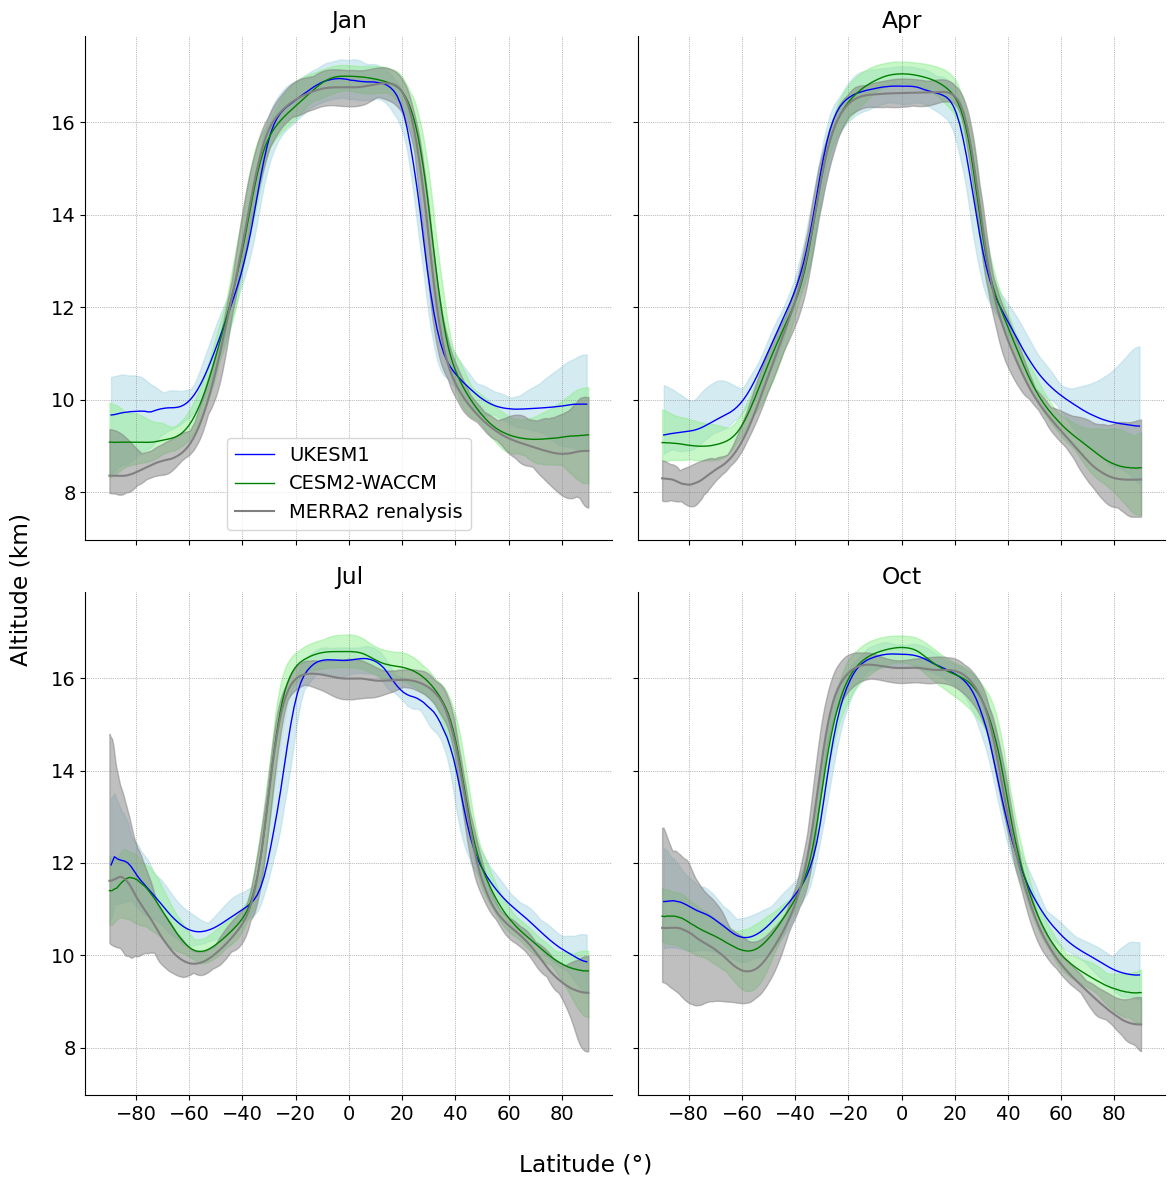

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
months = [1, 4, 7, 10]
titles = ['Jan', 'Apr', 'Jul', 'Oct']
i=0
reanalysis = 'MERRA2' # fairly central estimate and has full timeseries

for ax in axs.flatten():
        
    month = months[i]

    DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month == month, drop=True)
    DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month == month, drop=True)
    
    mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
    mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()

    ax.plot(mean_trop_U.y.values, mean_trop_U.values, label='UKESM1', color='blue', lw=1)
    ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
                color='lightblue', alpha=0.5)

    ax.plot(mean_trop_C.y.values, mean_trop_C.values, label='CESM2-WACCM', color='green', lw=1)
    ax.fill_between(mean_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
                color='lightgreen', alpha=0.5)

    df = DF[DF['Month']==month]
    df = df[df['Reanalysis']==reanalysis]
    df_max = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_km'], df_max['ztp_km'], 
                color='gray', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_km'], color='gray', label='{} renalysis'.format(reanalysis))
    

    
    ax.set_xticks(np.arange(-80, 85, 20))
    if i == 0:
        ax.legend()
    ax.set_title(titles[i])
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
    i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()

#plt.savefig('Figures/Tropopause_y2y_variabitliy_UKESMandCESM_vs_reanalyses.jpg', dpi=300)

In [15]:
## read in the dynamical tropopause data for ERA5

## NB the dynamical tropopause definition used here (by Hoffman and Spang) is 
##  (based on thresholds of 3.5 potential vorticity units in the extratropics and 380 K of potential temperature in the tropics)

root = '/gws/ssde/j25b/cpom/aduffey/Tropopause/zonal_means_dyn_HoffmanSpang/'
#dir = root+reanalysis+'/'

dfs_all = []
reanalyses = ['ERA5']

for reanalysis in reanalyses:
    dir = root+reanalysis+'/'
    dfs_reanalysis = []
    for file in os.listdir(dir):
        year = file.split('_')[-2]
        month = file.split('_')[-1].split('.')[0]
        if int(year) >= int(assessment_period[0]) and int(year) <= int(assessment_period[1]):
            df = pd.read_csv(dir+file, 
                        delimiter=" ",
                        skiprows=14,
                        header=None)
            df = df.iloc[:, 0:3] 
            df.columns = ['time [s]',
                          'latitude [deg]',
                          'tropopause height (mean) [km]']
            grid_lat_new = np.arange(-90, 90.1, 0.1)
            regridded_ztp = griddata(df['latitude [deg]'], df['tropopause height (mean) [km]'], grid_lat_new, method='linear')
            df_regridded = pd.DataFrame({'Latitude_deg':grid_lat_new,
                                         'ztp_dyn_km':regridded_ztp})
            df_regridded['Year'] = year
            df_regridded['Month'] = month
            df_regridded['Reanalysis'] = reanalysis
            dfs_reanalysis.append(df_regridded)
    df_reanalysis = pd.concat(dfs_reanalysis)
    dfs_all.append(df_reanalysis)
DF_dyn = pd.concat(dfs_all)
DF_dyn['Month'] = [int(x) for x in DF_dyn['Month']]
DF_dyn['Year'] = [int(x) for x in DF_dyn['Year']]


In [16]:
DF_dyn

,Latitude_deg,ztp_dyn_km,Year,Month,Reanalysis
0,-90.0,9.613040,2004,8,ERA5
1,-89.9,9.613107,2004,8,ERA5
2,-89.8,9.613173,2004,8,ERA5
3,-89.7,9.613240,2004,8,ERA5
4,-89.6,9.613290,2004,8,ERA5
...,...,...,...,...,...
1796,89.6,8.626037,2004,7,ERA5
1797,89.7,8.625690,2004,7,ERA5
1798,89.8,8.625280,2004,7,ERA5
1799,89.9,8.624870,2004,7,ERA5


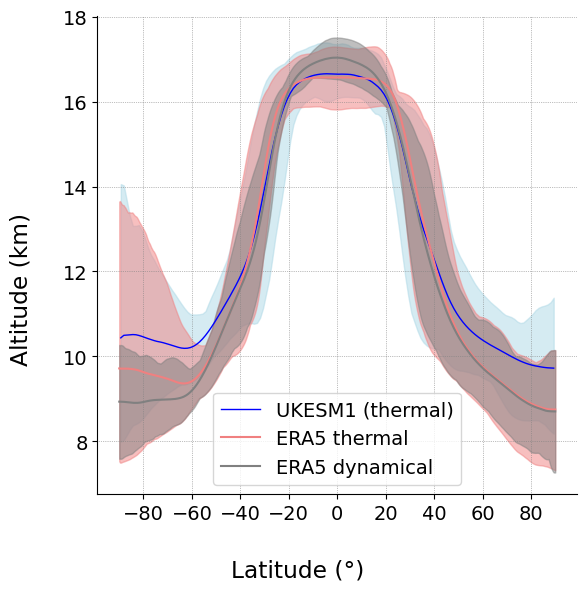

In [17]:
## annual mean version

## also plot the year-to-year variability for one member, and for MERRA2:

month = 1

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1.max(dim='time').ztp/1000).load(), (DS_UKESM_E1.min(dim='time').ztp/1000).load()

fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharex=True, sharey=True)
#months = [1, 4, 7, 10]
#titles = ['Jan', 'Apr', 'Jul', 'Oct']
#i=0
reanalysis = 'ERA5' 

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1.max(dim='time').ztp/1000).load(), (DS_UKESM_E1.min(dim='time').ztp/1000).load()

ax.plot(mean_trop_U.y.values, mean_trop_U.values, label='UKESM1 (thermal)', color='blue', lw=1)
ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
            color='lightblue', alpha=0.5)

#df = DF[DF['Month']==month]
df = DF[DF['Reanalysis']==reanalysis]
df_max = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).max().reset_index()
df_min = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).min().reset_index()
df_mean = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).mean().reset_index()
ax.fill_between(df_max['Latitude_deg'], df_min['ztp_km'], df_max['ztp_km'], 
            color='lightcoral', alpha=0.5)
ax.plot(df_mean['Latitude_deg'], df_mean['ztp_km'], 
        color='lightcoral', label='{} thermal'.format(reanalysis))

df = DF_dyn[DF_dyn['Reanalysis']==reanalysis]
df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
            color='gray', alpha=0.5)
ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], 
        color='gray', label='{} dynamical'.format(reanalysis))



ax.set_xticks(np.arange(-80, 85, 20))
#if i == 0:
ax.legend()
#ax.set_title(titles[i])
ax.spines[['right', 'top']].set_visible(False)
ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
    
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()

#plt.savefig('Figures/Tropopause_y2y_variabitliy_UKESMandCESM_vs_reanalyses.jpg', dpi=300)

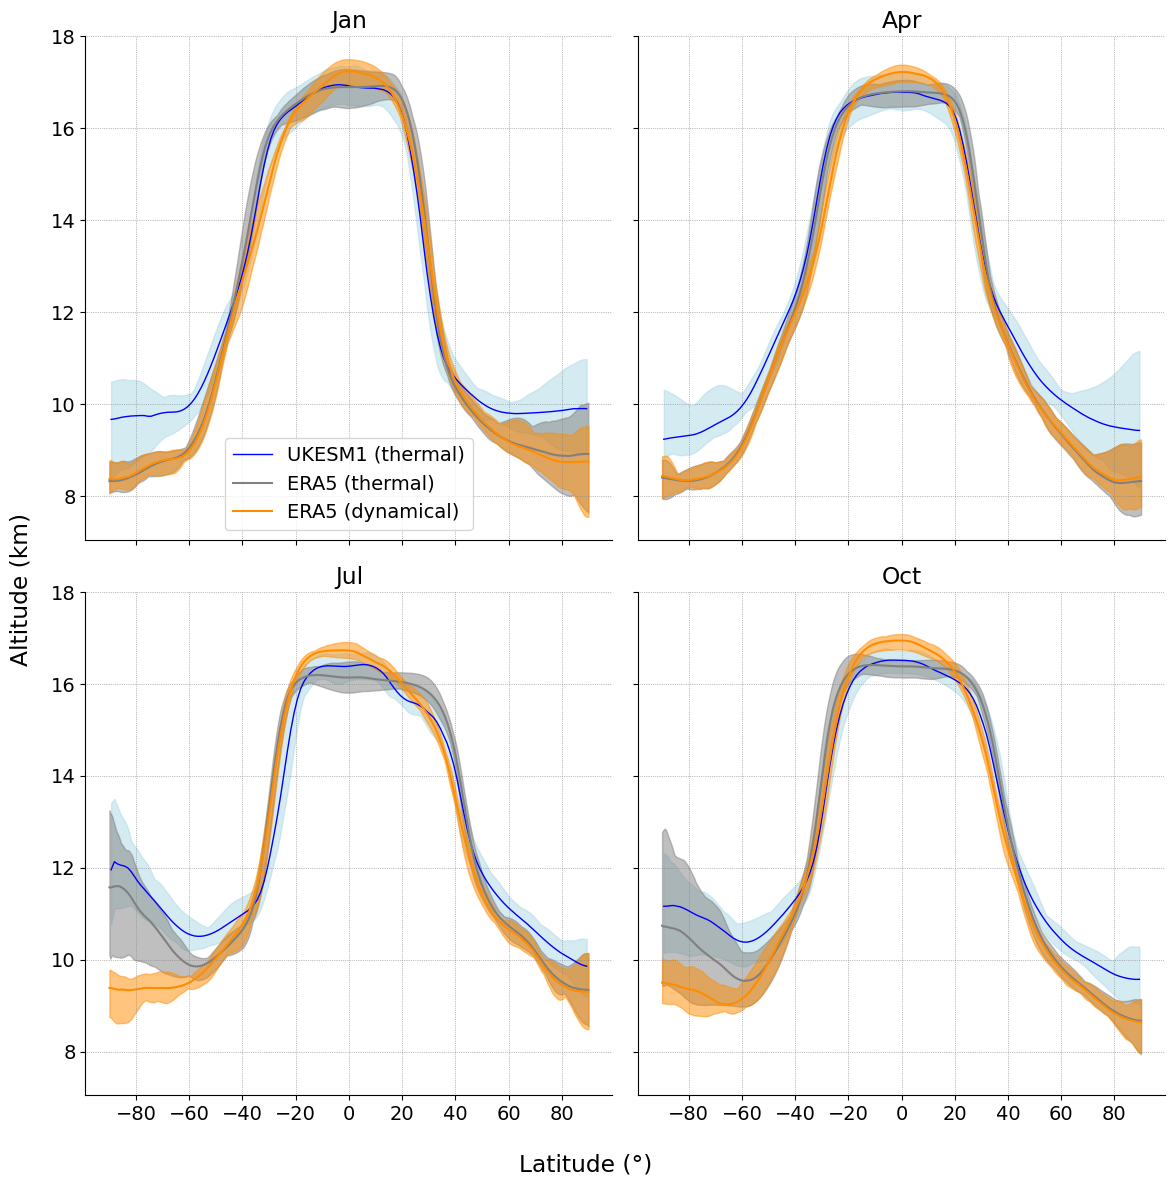

In [18]:
## also plot the year-to-year variability for one member:

month = 1

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1.max(dim='time').ztp/1000).load(), (DS_UKESM_E1.min(dim='time').ztp/1000).load()

fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
months = [1, 4, 7, 10]
titles = ['Jan', 'Apr', 'Jul', 'Oct']
i=0
reanalysis = 'ERA5' 

for ax in axs.flatten():
        
    month = months[i]

    DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month == month, drop=True)
    DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month == month, drop=True)
    
    mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
    mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()

    ax.plot(mean_trop_U.y.values, mean_trop_U.values, label='UKESM1 (thermal)', color='blue', lw=1)
    ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
                color='lightblue', alpha=0.5)

    df = DF[DF['Month']==month]
    df = df[df['Reanalysis']==reanalysis]
    df_max = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_km'], df_max['ztp_km'], 
                color='gray', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_km'], color='gray', label='{} (thermal)'.format(reanalysis))
    
    df = DF_dyn[DF_dyn['Month']==month]
    df = df[df['Reanalysis']==reanalysis]
    df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
                color='darkorange', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], color='darkorange', label='{} (dynamical)'.format(reanalysis))

    
    ax.set_xticks(np.arange(-80, 85, 20))
    if i == 0:
        ax.legend(loc='lower center')
    ax.set_title(titles[i])
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
    i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()

#plt.savefig('Figures/Tropopause_y2y_variabitliy_UKESMandCESM_vs_reanalyses.jpg', dpi=300)

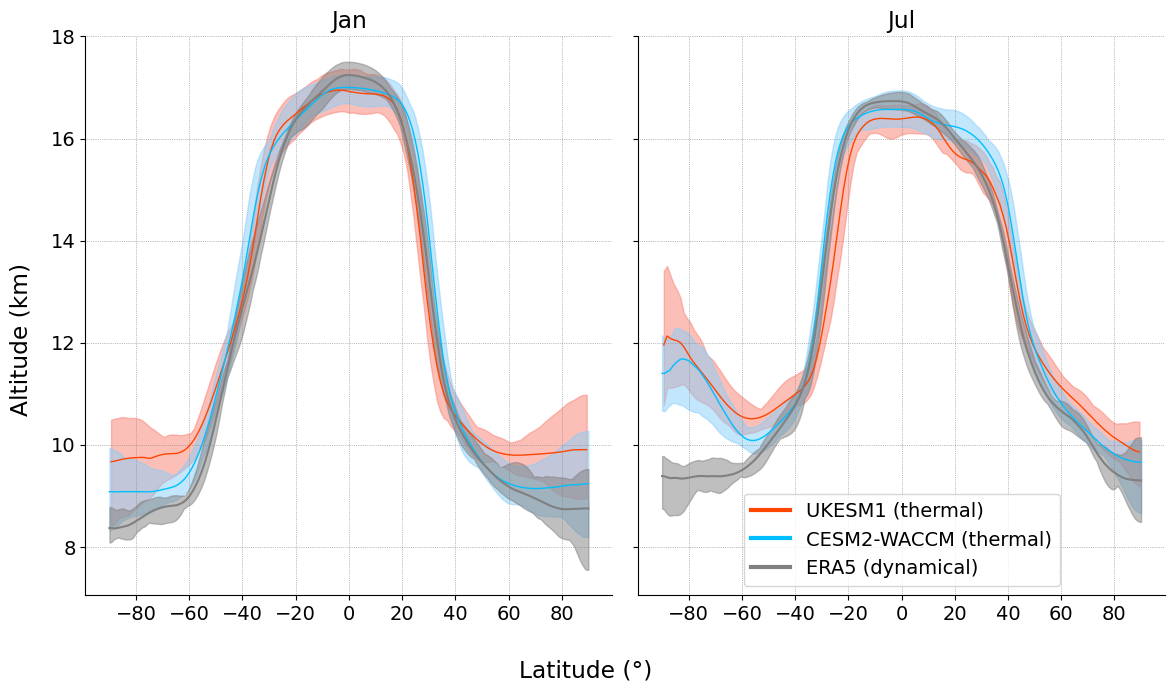

In [19]:
### repeat the above fig, now just for jan and jul, and also including CESM2:

## also plot the year-to-year variability for one member:

month = 1

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1.max(dim='time').ztp/1000).load(), (DS_UKESM_E1.min(dim='time').ztp/1000).load()

fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharex=True, sharey=True)
months = [1, 7]
titles = ['Jan', 'Jul']
i=0
reanalysis = 'ERA5' 

for ax in axs:
        
    month = months[i]

    DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month == month, drop=True)
    DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month == month, drop=True)
    
    mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
    mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()

    ax.plot(mean_trop_U.y.values, mean_trop_U.values, color=dark_model_colors['UKESM'], lw=1)
    ax.plot([], [], label='UKESM1 (thermal)', color=dark_model_colors['UKESM'], lw=3)
    ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
                color=model_colors['UKESM'], alpha=0.5)

    ax.plot(mean_trop_C.y.values, mean_trop_C.values, color=dark_model_colors['CESM'], lw=1)
    ax.plot([], [], label='CESM2-WACCM (thermal)', color=dark_model_colors['CESM'], lw=3)
    ax.fill_between(mean_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
                color=model_colors['CESM'], alpha=0.5)

    """
    df = DF[DF['Month']==month]
    df = df[df['Reanalysis']==reanalysis]
    df_max = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_km'], df_max['ztp_km'], 
                color='gray', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_km'], color='gray')
    ax.plot([], [], lw=3, color='gray', label='{} (thermal)'.format(reanalysis))
    """
    
    df = DF_dyn[DF_dyn['Month']==month]
    df = df[df['Reanalysis']==reanalysis]
    df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
    df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
    df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
    ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
                color='gray', alpha=0.5)
    ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], color='gray')
    ax.plot([], [], lw=3, color='gray', label='{} (dynamical)'.format(reanalysis))

    
    ax.set_xticks(np.arange(-80, 85, 20))
    if i == 1:
        ax.legend(loc='lower center')
    ax.set_title(titles[i])
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
    i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()

plt.savefig('Figures/Tropopause_summary.jpg', dpi=300)

In [20]:
df = DF_dyn[DF_dyn['Month'].isin(months)]
df = df[df['Reanalysis']==reanalysis]
df = df[df['Latitude_deg']>10]
df

,Latitude_deg,ztp_dyn_km,Year,Month,Reanalysis
1001,10.1,17.105733,2005,1,ERA5
1002,10.2,17.103500,2005,1,ERA5
1003,10.3,17.101100,2005,1,ERA5
1004,10.4,17.098700,2005,1,ERA5
1005,10.5,17.096300,2005,1,ERA5
...,...,...,...,...,...
1796,89.6,8.626037,2004,7,ERA5
1797,89.7,8.625690,2004,7,ERA5
1798,89.8,8.625280,2004,7,ERA5
1799,89.9,8.624870,2004,7,ERA5


In [21]:
DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(5, 91))
DS_UKESM_E1_m

<xarray.Dataset> Size: 68kB
Dimensions:      (time: 48, bnds: 2, y: 68)
Coordinates:
  * time         (time) object 384B 1991-01-16 00:00:00 ... 2014-07-16 00:00:00
  * y            (y) float64 544B 5.625 6.875 8.125 9.375 ... 86.88 88.12 89.38
Dimensions without coordinates: bnds
Data variables:
    time_bounds  (time, bnds) object 768B dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bounds   (time, y, bnds) float64 52kB dask.array<chunksize=(48, 68, 2), meta=np.ndarray>
    lon_bounds   (time, bnds) float64 768B dask.array<chunksize=(48, 2), meta=np.ndarray>
    ztp          (time, y) float32 13kB dask.array<chunksize=(1, 68), meta=np.ndarray>

In [22]:
DS_UKESM_E1_m

<xarray.Dataset> Size: 68kB
Dimensions:      (time: 48, bnds: 2, y: 68)
Coordinates:
  * time         (time) object 384B 1991-01-16 00:00:00 ... 2014-07-16 00:00:00
  * y            (y) float64 544B 5.625 6.875 8.125 9.375 ... 86.88 88.12 89.38
Dimensions without coordinates: bnds
Data variables:
    time_bounds  (time, bnds) object 768B dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bounds   (time, y, bnds) float64 52kB dask.array<chunksize=(48, 68, 2), meta=np.ndarray>
    lon_bounds   (time, bnds) float64 768B dask.array<chunksize=(48, 2), meta=np.ndarray>
    ztp          (time, y) float32 13kB dask.array<chunksize=(1, 68), meta=np.ndarray>

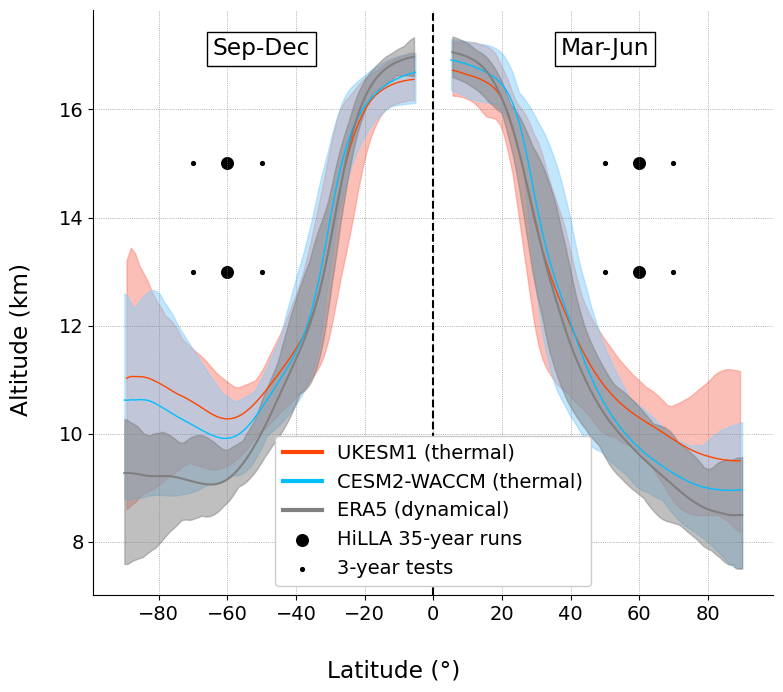

In [23]:
### try a mixed season figure, MAMJ Northern and SOND southern: 



mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1.max(dim='time').ztp/1000).load(), (DS_UKESM_E1.min(dim='time').ztp/1000).load()

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
reanalysis = 'ERA5' 

## NH        
months = [3,4,5,6]
subtitle = 'Mar-Jun'

DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(5, 91))
DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(5, 91))

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()

ax.plot(mean_trop_U.y.values, mean_trop_U.values, color=dark_model_colors['UKESM'], lw=1)
ax.plot([], [], label='UKESM1 (thermal)', color=dark_model_colors['UKESM'], lw=3)
ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
            color=model_colors['UKESM'], alpha=0.5)

ax.plot(mean_trop_C.y.values, mean_trop_C.values, color=dark_model_colors['CESM'], lw=1)
ax.plot([], [], label='CESM2-WACCM (thermal)', color=dark_model_colors['CESM'], lw=3)
ax.fill_between(mean_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
            color=model_colors['CESM'], alpha=0.5)

df = DF_dyn[DF_dyn['Month'].isin(months)]
df = df[df['Reanalysis']==reanalysis]
df = df[df['Latitude_deg']>5.5]
df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
            color='gray', alpha=0.5)
ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], color='gray')
ax.plot([], [], lw=3, color='gray', label='{} (dynamical)'.format(reanalysis))
ax.text(50, 17, subtitle, fontsize='large', ha='center', bbox=dict(facecolor='white'))
 

## SH        
months = [9,10,11,12]
subtitle = 'Sep-Dec'

DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(-91, -5))
DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(-91, -5))

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()

ax.plot(mean_trop_U.y.values, mean_trop_U.values, color=dark_model_colors['UKESM'], lw=1)
#ax.plot([], [], label='UKESM1 (thermal)', color=dark_model_colors['UKESM'], lw=3)
ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
            color=model_colors['UKESM'], alpha=0.5)

ax.plot(mean_trop_C.y.values, mean_trop_C.values, color=dark_model_colors['CESM'], lw=1)
#ax.plot([], [], label='CESM2-WACCM (thermal)', color=dark_model_colors['CESM'], lw=3)
ax.fill_between(mean_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
            color=model_colors['CESM'], alpha=0.5)

df = DF_dyn[DF_dyn['Month'].isin(months)]
df = df[df['Reanalysis']==reanalysis]
df = df[df['Latitude_deg']<-5.6]
df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
            color='gray', alpha=0.5)
ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], color='gray')
#ax.plot([], [], lw=3, color='gray', label='{} (dynamical)'.format(reanalysis))
ax.text(-50, 17, subtitle, fontsize='large', ha='center', bbox=dict(facecolor='white'))

ax.scatter([-60, 60], [13, 13], marker='o', c='black', s=70)
ax.scatter([-60, 60], [15, 15], marker='o', c='black', s=70, label='HiLLA 35-year runs')

ax.scatter([-70, -50, 50, 70], [13, 13, 13, 13], marker='.', c='black', s=30, label='3-year tests')
ax.scatter([-70, -50, 50, 70], [15, 15, 15, 15], marker='.', c='black', s=30)



ax.set_xticks(np.arange(-80, 85, 20))
ax.legend(loc='lower center', framealpha=1)

plt.axvline(x=0, color='black', linestyle='--')

ax.spines[['right', 'top']].set_visible(False)
ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()

plt.savefig('Figures/HiLLA_locations_tropopause_summary.jpg', dpi=300)

In [24]:
## also add E3SM 
def seasonal_time_slice(ds, start_yr_str='2050', end_yr_str='2069'):
    ds = ds.sel(time=slice(start_yr_str, end_yr_str)).groupby('time.month').mean(dim='time')
    return ds
from HiLLA_utils import set_time_to_center_of_bounds
ds_E3SM = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/TROP_P/TROP_P.polar.mip.e3sm.control.nc'), 'time_bnds').sel(time=slice('2035', '2050')).mean('lon')
ds_Z3_ssp245_E3_mn = xr.open_dataset(path_archive+'E3SM_data/regridded/Z3_seasonal/Z3.polar.mip.e3sm.control_seas_mean.nc').mean(['lon', 'season']).load()#.sel(lev=slice(None, None, -1)) # already took the time slice for e3sm before regridding, also note flipping the levels (if applicable)
ds_Z3_ssp245_E3_mn['lev'] = ds_Z3_ssp245_E3_mn['lev']*100 # convert to Pa


In [26]:
def get_Trop_Z_E3SM(ds_trop_P):
    TROP_P_as_level = ds_trop_P['TROP_P'].rename('lev')
    return ds_Z3_ssp245_E3_mn['Z3'].interp(lev=TROP_P_as_level, method='linear')


In [27]:
ds_Z3_ssp245_E3_mn

<xarray.Dataset> Size: 65kB
Dimensions:   (lat: 180, nbnd: 2, lev: 80)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lev       (lev) float64 640B 12.36 18.19 26.74 ... 9.938e+04 9.985e+04
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds  (lat, nbnd) float64 3kB -90.0 -89.0 -89.0 -88.0 ... 89.0 89.0 90.0
    lon_bnds  (nbnd) float64 16B 179.5 180.5
    gw        (lat) float64 1kB 0.0001523 0.0004569 ... 0.0004569 0.0001523
    area      (lat) float64 1kB 2.658e-06 7.973e-06 ... 7.973e-06 2.658e-06
    Z3        (lev, lat) float32 58kB 6.143e+04 6.143e+04 ... 11.74 11.74

In [28]:
ds_E3SM

<xarray.Dataset> Size: 150kB
Dimensions:    (lat: 180, nbnd: 2, time: 192)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * time       (time) object 2kB 2035-01-16 12:00:00 ... 2050-12-16 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds   (lat, nbnd) float64 3kB -90.0 -89.0 -89.0 ... 89.0 89.0 90.0
    lon_bnds   (nbnd) float64 16B 179.5 180.5
    gw         (lat) float64 1kB 0.0001523 0.0004569 ... 0.0004569 0.0001523
    area       (lat) float64 1kB 2.658e-06 7.973e-06 ... 7.973e-06 2.658e-06
    TROP_P     (time, lat) float32 138kB 2.929e+04 2.928e+04 ... 3.17e+04
    time_bnds  (time, nbnd) object 3kB 2035-01-01 00:00:00 ... 2051-01-01 00:...

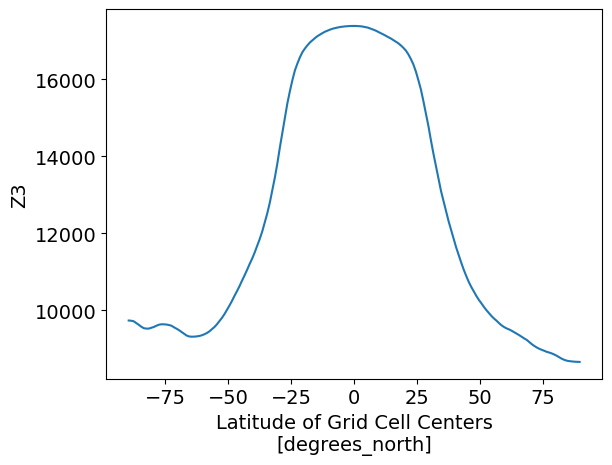

In [29]:
get_Trop_Z_E3SM(ds_E3SM.mean('time')).plot()


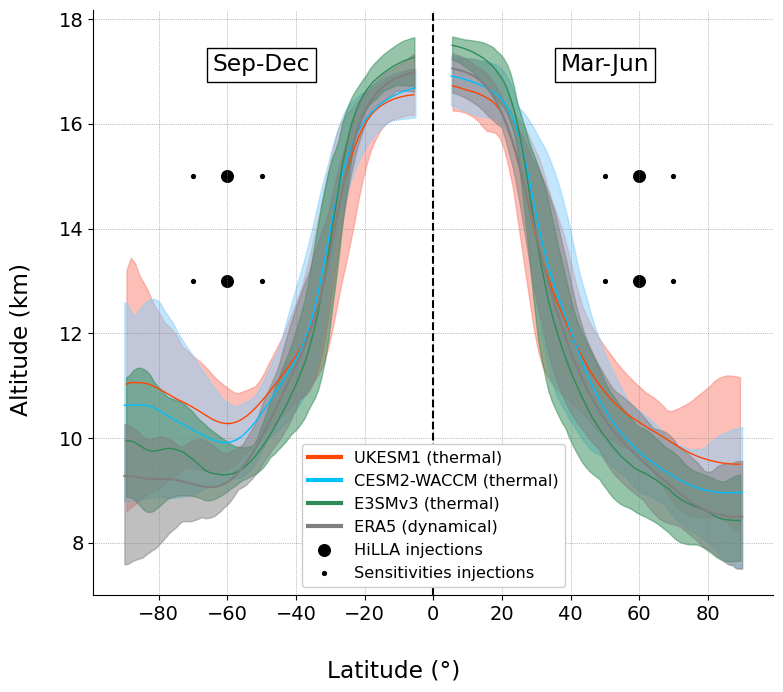

In [30]:
### repeat the mixed season figure, MAMJ Northern and SOND southern, now with E3SM included: 



mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1.max(dim='time').ztp/1000).load(), (DS_UKESM_E1.min(dim='time').ztp/1000).load()

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
reanalysis = 'ERA5' 

## NH        
months = [3,4,5,6]
subtitle = 'Mar-Jun'

DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(5, 91))
DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(5, 91))
ds_E3SM_m = ds_E3SM.where(ds_E3SM.time.dt.month.isin(months), drop=True)

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_E, max_trop_E, min_trop_E = 0.001*get_Trop_Z_E3SM(ds_E3SM_m.mean(dim='time')).sel(lat=slice(5, 91)), 0.001*get_Trop_Z_E3SM(ds_E3SM_m.max(dim='time')).sel(lat=slice(5, 91)), 0.001*get_Trop_Z_E3SM(ds_E3SM_m.min(dim='time')).sel(lat=slice(5, 91))
                                       
ax.plot(mean_trop_U.y.values, mean_trop_U.values, color=dark_model_colors['UKESM'], lw=1)
ax.plot([], [], label='UKESM1 (thermal)', color=dark_model_colors['UKESM'], lw=3)
ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
            color=model_colors['UKESM'], alpha=0.5)

ax.plot(mean_trop_C.y.values, mean_trop_C.values, color=dark_model_colors['CESM'], lw=1)
ax.plot([], [], label='CESM2-WACCM (thermal)', color=dark_model_colors['CESM'], lw=3)
ax.fill_between(mean_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
            color=model_colors['CESM'], alpha=0.5)

ax.plot(mean_trop_E.lat.values, mean_trop_E.values, color=dark_model_colors['E3SM'], lw=1)
ax.plot([], [], label='E3SMv3 (thermal)', color=dark_model_colors['E3SM'], lw=3)
ax.fill_between(mean_trop_E.lat.values, min_trop_E.values, max_trop_E.values, 
            color=model_colors['E3SM'], alpha=0.5)

df = DF_dyn[DF_dyn['Month'].isin(months)]
df = df[df['Reanalysis']==reanalysis]
df = df[df['Latitude_deg']>5.5]
df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
            color='gray', alpha=0.5)
ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], color='gray')
ax.plot([], [], lw=3, color='gray', label='{} (dynamical)'.format(reanalysis))
ax.text(50, 17, subtitle, fontsize='large', ha='center', bbox=dict(facecolor='white'))
 

## SH        
months = [9,10,11,12]
subtitle = 'Sep-Dec'

DS_UKESM_E1_m = DS_UKESM_E1.where(DS_UKESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(-91, -5))
DS_CESM_E1_m = DS_CESM_E1.where(DS_CESM_E1.time.dt.month.isin(months), drop=True).sel(y=slice(-91, -5))
ds_E3SM_m = ds_E3SM.where(ds_E3SM.time.dt.month.isin(months), drop=True)

mean_trop_U, max_trop_U, min_trop_U = (DS_UKESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.max(dim='time').ztp/1000).load(), (DS_UKESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_C, max_trop_C, min_trop_C = (DS_CESM_E1_m.mean(dim='time').ztp/1000).load(), (DS_CESM_E1_m.max(dim='time').ztp/1000).load(), (DS_CESM_E1_m.min(dim='time').ztp/1000).load()
mean_trop_E, max_trop_E, min_trop_E = 0.001*get_Trop_Z_E3SM(ds_E3SM_m.mean(dim='time')).sel(lat=slice(-91, -5)), 0.001*get_Trop_Z_E3SM(ds_E3SM_m.max(dim='time')).sel(lat=slice(-91, -5)), 0.001*get_Trop_Z_E3SM(ds_E3SM_m.min(dim='time')).sel(lat=slice(-91, -5))
 
ax.plot(mean_trop_U.y.values, mean_trop_U.values, color=dark_model_colors['UKESM'], lw=1)
#ax.plot([], [], label='UKESM1 (thermal)', color=dark_model_colors['UKESM'], lw=3)
ax.fill_between(mean_trop_U.y.values, min_trop_U.values, max_trop_U.values, 
            color=model_colors['UKESM'], alpha=0.5)

ax.plot(mean_trop_C.y.values, mean_trop_C.values, color=dark_model_colors['CESM'], lw=1)
#ax.plot([], [], label='CESM2-WACCM (thermal)', color=dark_model_colors['CESM'], lw=3)
ax.fill_between(mean_trop_C.y.values, min_trop_C.values, max_trop_C.values, 
            color=model_colors['CESM'], alpha=0.5)

ax.plot(mean_trop_E.lat.values, mean_trop_E.values, color=dark_model_colors['E3SM'], lw=1)
#ax.plot([], [], label='E3SMv3 (thermal)', color=dark_model_colors['E3SM'], lw=3)
ax.fill_between(mean_trop_E.lat.values, min_trop_E.values, max_trop_E.values, 
            color=model_colors['E3SM'], alpha=0.5)

df = DF_dyn[DF_dyn['Month'].isin(months)]
df = df[df['Reanalysis']==reanalysis]
df = df[df['Latitude_deg']<-5.6]
df_max = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).max().reset_index()
df_min = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).min().reset_index()
df_mean = df[['Latitude_deg', 'ztp_dyn_km']].groupby(['Latitude_deg']).mean().reset_index()
ax.fill_between(df_max['Latitude_deg'], df_min['ztp_dyn_km'], df_max['ztp_dyn_km'], 
            color='gray', alpha=0.5)
ax.plot(df_mean['Latitude_deg'], df_mean['ztp_dyn_km'], color='gray')
#ax.plot([], [], lw=3, color='gray', label='{} (dynamical)'.format(reanalysis))
ax.text(-50, 17, subtitle, fontsize='large', ha='center', bbox=dict(facecolor='white'))

ax.scatter([-60, 60], [13, 13], marker='o', c='black', s=70)
ax.scatter([-60, 60], [15, 15], marker='o', c='black', s=70, label='HiLLA injections')

ax.scatter([-70, -50, 50, 70], [13, 13, 13, 13], marker='.', c='black', s=30, label='Sensitivities injections')
ax.scatter([-70, -50, 50, 70], [15, 15, 15, 15], marker='.', c='black', s=30)



ax.set_xticks(np.arange(-80, 85, 20))
ax.legend(loc='lower center', framealpha=1, fontsize='small')

plt.axvline(x=0, color='black', linestyle='--')

ax.spines[['right', 'top']].set_visible(False)
ax.grid(color = 'gray', linestyle = 'dotted', linewidth = 0.5)
i=i+1
fig.supylabel('Altitude (km)')
fig.supxlabel('Latitude (°)')
plt.tight_layout()

plt.savefig('Figures/HiLLA_locations_tropopause_summary_v2.jpg', dpi=350, bbox_inches='tight')

In [ ]:
### also save some trop Z netcdfs, for use in the ozone plotting later: 

